## Phase 1 data understanding

In [6]:
import pandas as pd


In [7]:
df = pd.read_csv("fake_job_postings.csv")

In [8]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [9]:
df.shape

(17880, 18)

In [10]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [12]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [13]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


**Example for understanding**

Dataset contains 17,880 records.
18 columns available.
Target variable is fraudulent.
Most columns contain text.
Some columns have many missing values.
Fraud cases are much fewer than genuine cases.

Phase 2 About Data Cleaning & Preprocessing
means conversion of raw data into clean

In [14]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [15]:
df = df.fillna("")

In [16]:
df.shape

(17880, 18)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df = df.drop_duplicates()

In [19]:
df.shape

(17880, 18)

In [20]:
df["text"] = (
    df["title"].astype(str) + " " +
    df["company_profile"].astype(str) + " " +
    df["description"].astype(str) + " " +
    df["requirements"].astype(str)
)

In [21]:
df["text"].head()

,text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC Our passion ...
4,Bill Review Manager SpotSource Solutions LLC i...


In [22]:
import re

In [23]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [24]:
df["text"] = df["text"].apply(clean_text)

In [25]:
df["text"].head()

,text
0,marketing intern we re food and we ve created ...
1,customer service cloud video production second...
2,commissioning machinery assistant cma valor se...
3,account executive washington dc our passion fo...
4,bill review manager spotsource solutions llc i...


In [26]:
df.isnull().sum()

,0
job_id,0
title,0
location,0
department,0
salary_range,0
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17880 non-null  object
 3   department           17880 non-null  object
 4   salary_range         17880 non-null  object
 5   company_profile      17880 non-null  object
 6   description          17880 non-null  object
 7   requirements         17880 non-null  object
 8   benefits             17880 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      17880 non-null  object
 13  required_experience  17880 non-null  object
 14  required_education   17880 non-null  object
 15  industry             17880 non-null  object
 16  func

In [28]:
df.to_csv("cleaned_jobs.csv", index=False)

### PHASE 3  EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

In [29]:
df = pd.read_csv("cleaned_jobs.csv")

In [30]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


In [31]:
import os
os.listdir()

['.config', 'cleaned_jobs.csv', 'fake_job_postings.csv', 'sample_data']

FRAUD vs GENUINE

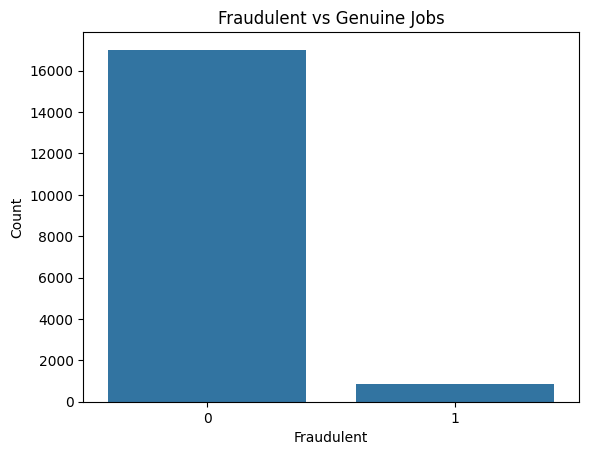

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='fraudulent', data=df)

plt.title("Fraudulent vs Genuine Jobs")
plt.xlabel("Fraudulent")
plt.ylabel("Count")

plt.show()

FRAUD PERCENTAGE

In [38]:
df['fraudulent'].value_counts(normalize=True) * 100

,proportion
fraudulent,
0,95.1566
1,4.8434


PIE CHART

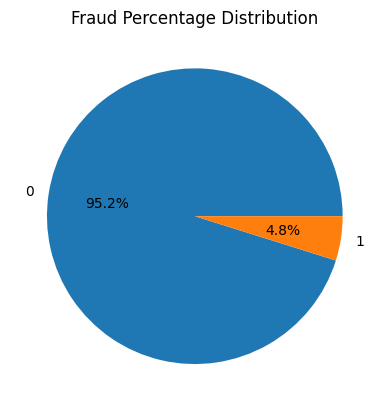

In [39]:
df['fraudulent'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Fraud Percentage Distribution")
plt.ylabel('')
plt.show()

BAR CHART

In [40]:
df['industry'].value_counts().head(10)

,count
industry,
Information Technology and Services,1734
Computer Software,1376
Internet,1062
Marketing and Advertising,828
Education Management,822
Financial Services,779
Hospital & Health Care,497
Consumer Services,358
Telecommunications,342


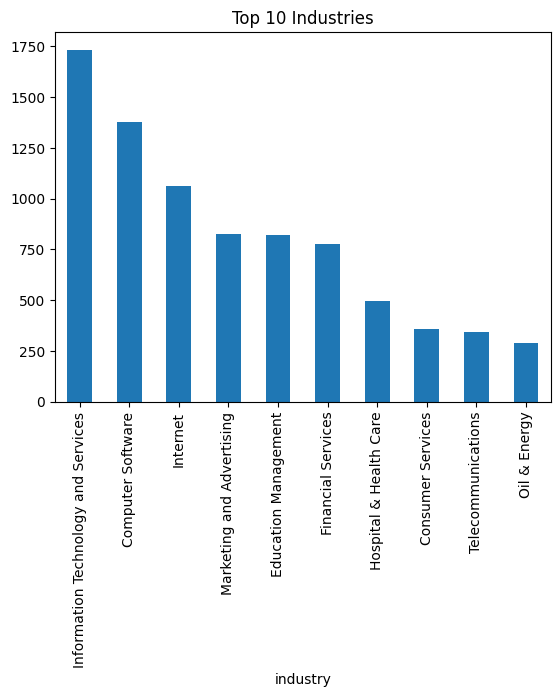

In [41]:
df['industry'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 Industries")
plt.show()

TOP INDUSTRIES  



In [42]:
df['industry'].value_counts().head(10)

,count
industry,
Information Technology and Services,1734
Computer Software,1376
Internet,1062
Marketing and Advertising,828
Education Management,822
Financial Services,779
Hospital & Health Care,497
Consumer Services,358
Telecommunications,342


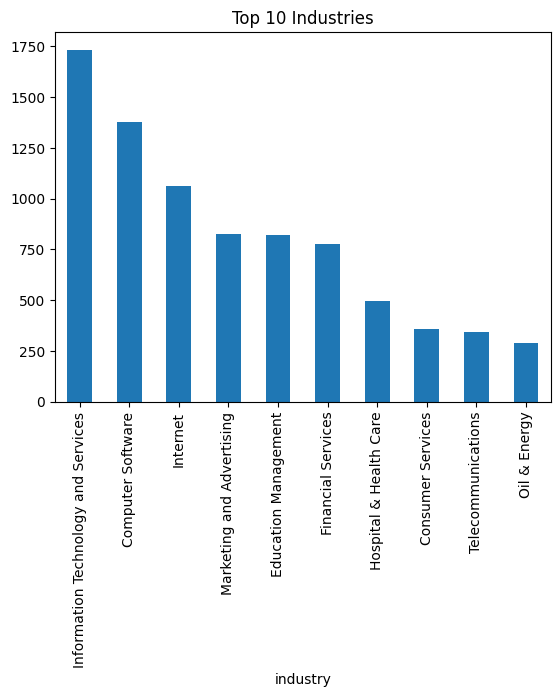

In [43]:
df['industry'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 Industries")
plt.show()

EMPLOYMENT TYPE ANALYSIS

In [44]:
df['employment_type'].value_counts()

,count
employment_type,
Full-time,11620
Contract,1524
Part-time,797
Temporary,241
Other,227


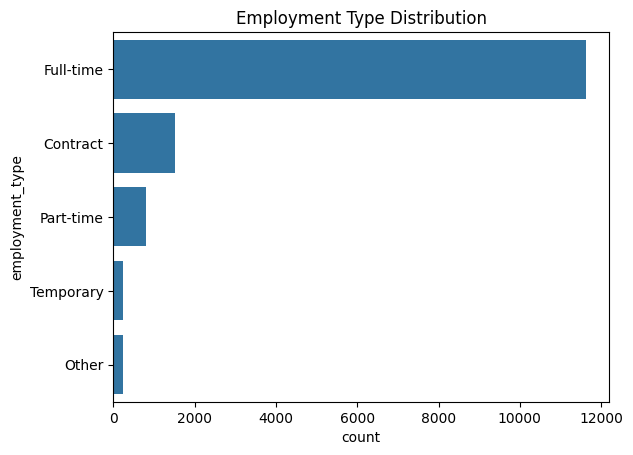

In [45]:
sns.countplot(
    y='employment_type',
    data=df,
    order=df['employment_type'].value_counts().index
)

plt.title("Employment Type Distribution")
plt.show()

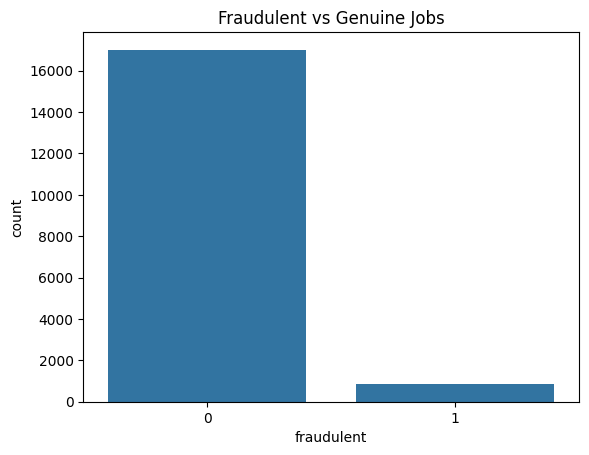

In [46]:
sns.countplot(x='fraudulent', data=df)

plt.title("Fraudulent vs Genuine Jobs")
plt.show()

The number of genuine job postings is significantly higher than fraudulent job postings.

Genuine postings: 17,014

Fraudulent postings: 866

This indicates that the dataset is highly imbalanced, with genuine jobs forming the majority of records.

REQUIRED EDUCATION ANALYSIS

In [47]:
df['required_education'].value_counts().head(10)

,count
required_education,
Bachelor's Degree,5145
High School or equivalent,2080
Unspecified,1397
Master's Degree,416
Associate Degree,274
Certification,170
Some College Coursework Completed,102
Professional,74
Vocational,49


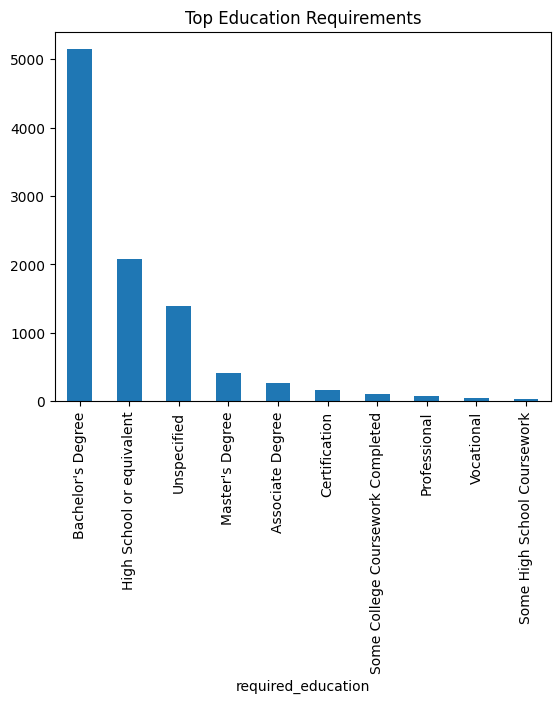

In [48]:
df['required_education'].value_counts().head(10).plot(kind='bar')

plt.title("Top Education Requirements")
plt.show()

REQUIRED EXPERIENCE ANALYSIS

In [49]:
df['required_experience'].value_counts().head(10)

,count
required_experience,
Mid-Senior level,3809
Entry level,2697
Associate,2297
Not Applicable,1116
Director,389
Internship,381
Executive,141


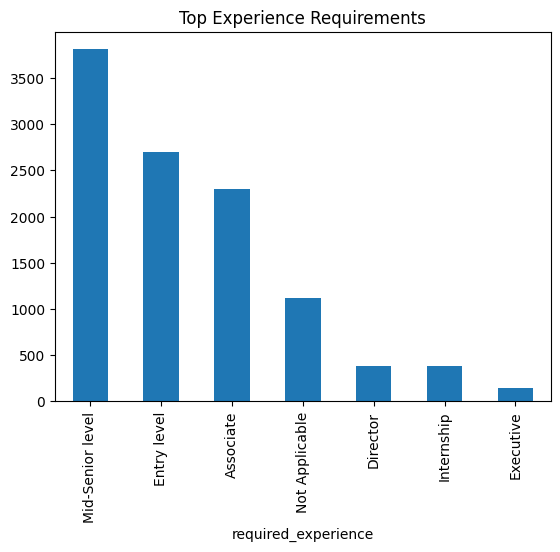

In [50]:
df['required_experience'].value_counts().head(10).plot(kind='bar')

plt.title("Top Experience Requirements")
plt.show()

Employment Type vs Fraud

In [51]:
pd.crosstab(
    df['employment_type'],
    df['fraudulent']
)

fraudulent,0,1
employment_type,,
Contract,1480,44
Full-time,11130,490
Other,212,15
Part-time,723,74
Temporary,239,2


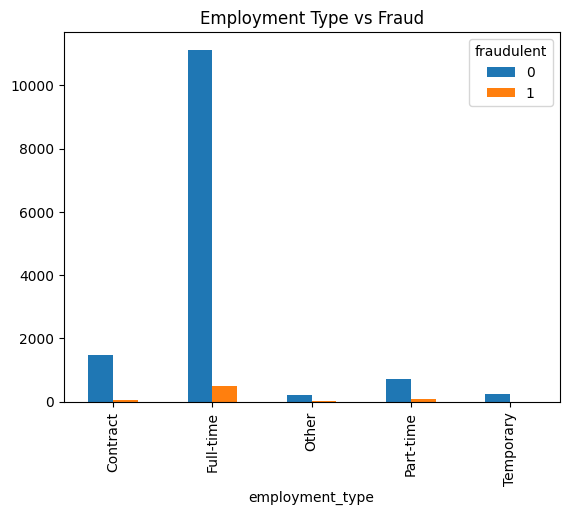

In [52]:
pd.crosstab(
    df['employment_type'],
    df['fraudulent']
).plot(kind='bar')

plt.title("Employment Type vs Fraud")
plt.show()

Industry vs Fraud

In [53]:
pd.crosstab(
    df['industry'],
    df['fraudulent']
).head(15)

fraudulent,0,1
industry,,
Accounting,102,57
Airlines/Aviation,62,1
Alternative Dispute Resolution,1,0
Animation,3,2
Apparel & Fashion,95,2
Architecture & Planning,10,0
Automotive,115,5
Aviation & Aerospace,24,0
Banking,81,3


  **TEXT ANALYSIS**

In [54]:
from collections import Counter

genuine_text = " ".join(
    df[df['fraudulent']==0]['text']
)

Counter(genuine_text.split()).most_common(20)

[('and', 329778),
 ('to', 189807),
 ('the', 185216),
 ('a', 148066),
 ('of', 138199),
 ('in', 117968),
 ('with', 82442),
 ('for', 76240),
 ('we', 68926),
 ('our', 61091),
 ('is', 58469),
 ('you', 52890),
 ('are', 41954),
 ('be', 37038),
 ('as', 36943),
 ('experience', 36842),
 ('on', 36601),
 ('or', 34268),
 ('that', 31990),
 ('work', 31284)]

In [55]:
fraud_text = " ".join(
    df[df['fraudulent']==1]['text']
)

Counter(fraud_text.split()).most_common(20)

[('and', 12623),
 ('to', 6994),
 ('the', 6146),
 ('a', 5095),
 ('of', 4576),
 ('in', 4077),
 ('with', 2976),
 ('for', 2854),
 ('is', 1754),
 ('experience', 1576),
 ('work', 1570),
 ('are', 1532),
 ('or', 1507),
 ('we', 1468),
 ('you', 1401),
 ('on', 1281),
 ('as', 1232),
 ('be', 1229),
 ('our', 1218),
 ('e', 1210)]

Genuine Word Cloud

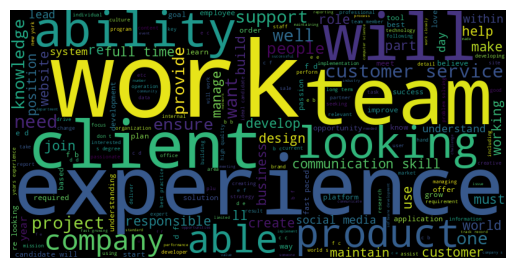

In [56]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400
).generate(genuine_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

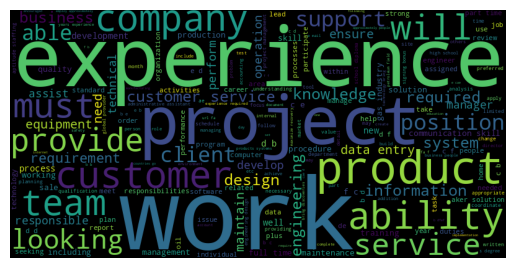

In [57]:
wordcloud = WordCloud(
    width=800,
    height=400
).generate(fraud_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

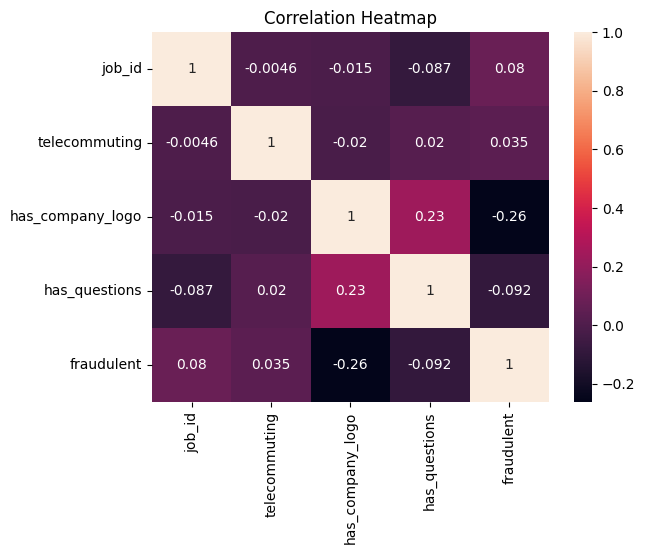

In [58]:
numeric_df = df.select_dtypes(include=['int64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

*Dataset Distribution
The dataset contains 17,880 job postings.
Genuine job postings (17,014) greatly outnumber fraudulent postings (866).
Fraudulent postings represent approximately 4.84% of the dataset.*

Industry Analysis
Information Technology and Services is the most common industry.
Computer Software and Internet sectors contribute a large number of postings.
Some industries have significantly fewer job postings than others.

**Employment Analysis
Full-time employment is the dominant employment type.
Contract and Part-time positions are much less frequent.
Temporary and Other categories contain relatively few records.**

Text Analysis



Common words in genuine postings include:
work
team
experience
client
ability
Fraudulent postings also use words such as:
work
experience
project
product
Text analysis indicates that fraud detection cannot rely on a single keyword and requires multiple features.




PHASE 3 CONCLUSION

EDA helped identify the distribution of fraud and genuine jobs,
understand industry and employment patterns,
analyze textual characteristics,
and discover relationships among variables.

The cleaned dataset is now ready for feature engineering
and machine learning model development